**Python** --> Python is a simple, easy-to-read programming language used to give instructions to a computer.

**Variables**
A variable is like a box that stores a value. You give it a name and put data in it.

**Data Types** 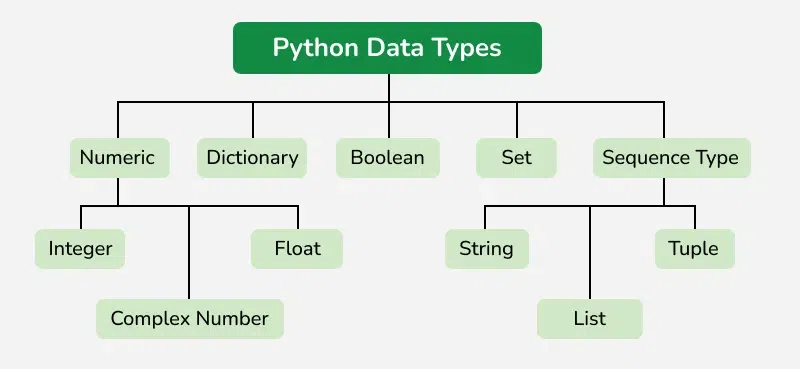

**For Loop**

A for loop is used to repeat something multiple times automatically.

 **While Loop** --> A while loop keeps repeating as long as a condition is TRUE.

 f-Else --
If-else is used to make decisions in your code.

**List**

A list is an ordered, mutable (changeable) collection of items in Python. It can hold elements of any data type and allows duplicates.

**Dictionary**

A dictionary is an unordered collection of key-value pairs. Each key must be unique, and it maps to a specific value.

In [ ]:
#Install & import
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    f1_score
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [ ]:
#Upload file
from google.colab import files
uploaded = files.upload()

Saving student_performance_updated_1000.csv to student_performance_updated_1000.csv


In [ ]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 1000 rows × 12 columns


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [ ]:
print('=== Dataset Info ===') # Data inforamtion
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


In [ ]:
print('=== Descriptive Statistics ===')
df.describe().round(2)

=== Descriptive Statistics ===


,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.00,960.00,950.00,967.00,957.00,960.00,976.00,959.00
mean,5416.02,85.51,17.63,77.60,1.52,80.03,2.41,77.25
std,2653.75,7.33,6.27,10.01,1.05,9.49,1.62,19.30
min,1.00,70.00,8.00,60.00,0.00,62.00,-5.00,50.00
25%,3113.50,82.00,12.00,70.00,1.00,72.00,1.20,63.00
50%,5396.50,88.00,18.00,78.00,1.00,80.00,2.50,76.00
75%,7754.75,91.00,22.00,86.00,2.00,88.00,3.70,89.00
max,9998.00,95.00,30.00,90.00,3.00,92.00,5.00,200.00


In [ ]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])

=== Missing Values ===
StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64


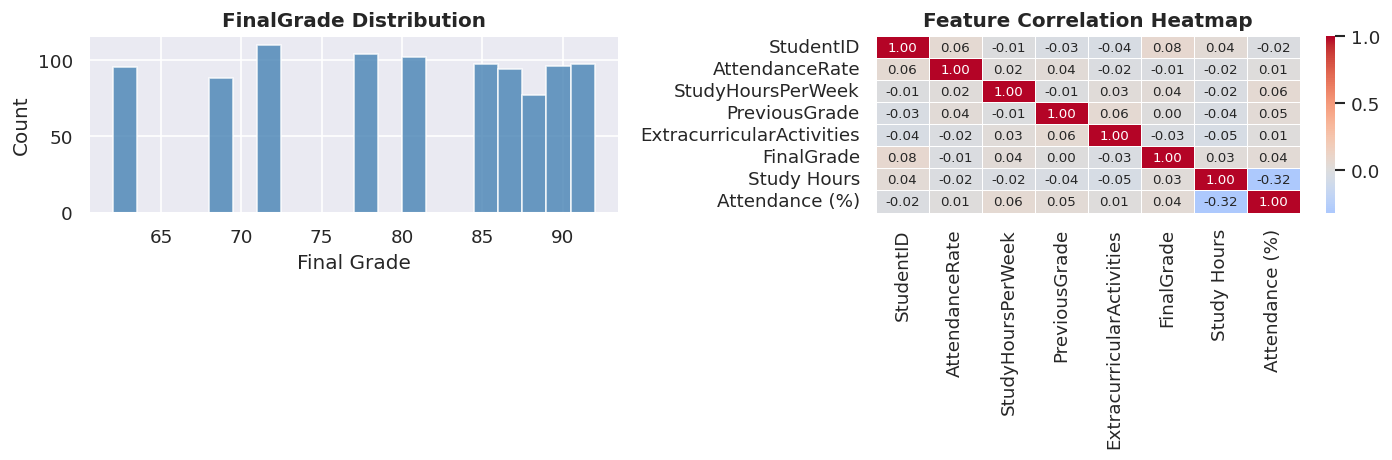

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['FinalGrade'].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('FinalGrade Distribution', fontweight='bold')
axes[0].set_xlabel('Final Grade')
axes[0].set_ylabel('Count')

num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
df_proc = df.copy()

le = LabelEncoder()
df_proc['ParentalSupport_enc'] = le.fit_transform(df_proc['ParentalSupport'].fillna('Low'))

df_proc['OnlineClasses_enc'] = df_proc['Online Classes Taken'].map(
    {'True': 1, 'False': 0, True: 1, False: 0}
).fillna(0).astype(int)

df_proc['Gender_enc'] = (df_proc['Gender'] == 'Male').astype(int)

FEATURES = [
    'AttendanceRate',
    'StudyHoursPerWeek',
    'PreviousGrade',
    'ExtracurricularActivities',
    'ParentalSupport_enc',
    'OnlineClasses_enc',
    'Gender_enc'
]
TARGET = 'FinalGrade'

df_clean = df_proc[FEATURES + [TARGET]].dropna().reset_index(drop=True)
print(f'✅ Clean dataset: {len(df_clean)} rows')
print(f'   Features used: {FEATURES}')

✅ Clean dataset: 819 rows
   Features used: ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport_enc', 'OnlineClasses_enc', 'Gender_enc']


In [ ]:
q33 = df_clean[TARGET].quantile(0.33)
q66 = df_clean[TARGET].quantile(0.66)

print(f'Low    : score ≤ {q33}')
print(f'Medium : {q33} < score ≤ {q66}')
print(f'High   : score > {q66}')

def categorize(score):
    if score <= q33:
        return 'Low'
    elif score <= q66:
        return 'Medium'
    else:
        return 'High'

df_clean['PerformanceCategory'] = df_clean[TARGET].apply(categorize)

print('\nClass distribution:')
print(df_clean['PerformanceCategory'].value_counts())

Low    : score ≤ 78.0
Medium : 78.0 < score ≤ 87.0
High   : score > 87.0

Class distribution:
PerformanceCategory
Low       342
Medium    254
High      223
Name: count, dtype: int64


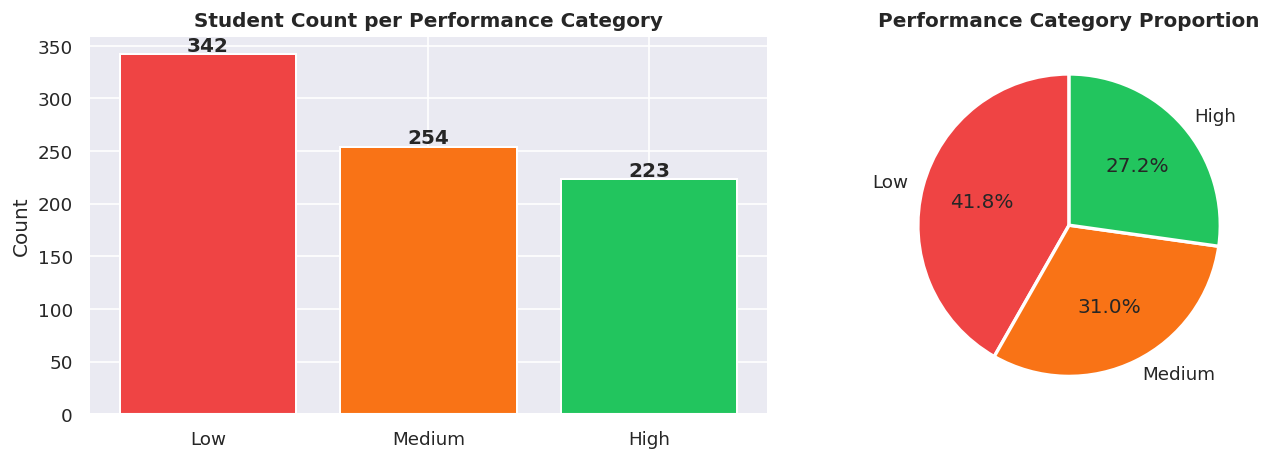

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_clean['PerformanceCategory'].value_counts().reindex(['Low', 'Medium', 'High'])
colors = ['#ef4444', '#f97316', '#22c55e']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Student Count per Performance Category', fontweight='bold')
axes[0].set_ylabel('Count')
for i, val in enumerate(counts.values):
    axes[0].text(i, val + 3, str(val), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Performance Category Proportion', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
X = df_clean[FEATURES]
y_class = df_clean['PerformanceCategory']
y_reg   = df_clean[TARGET]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class
)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

print(f'✅ Train size : {len(X_train_c)}')
print(f'   Test size  : {len(X_test_c)}')

✅ Train size : 655
   Test size  : 164


In [ ]:
clf = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42, C=1.0)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

print('✅ Multinomial Logistic Regression trained!')
print(f'   Classes : {clf.classes_}')

✅ Multinomial Logistic Regression trained!
   Classes : ['High' 'Low' 'Medium']


In [ ]:
accuracy = accuracy_score(y_test_c, y_pred_c)

print('=' * 45)
print(f'  CLASSIFICATION ACCURACY : {accuracy * 100:.2f}%')
print('=' * 45)

print('\nClassification Report:')
print(classification_report(y_test_c, y_pred_c,
                             labels=['Low', 'Medium', 'High'],
                             zero_division=0))

  CLASSIFICATION ACCURACY : 40.85%

Classification Report:
              precision    recall  f1-score   support

         Low       0.42      0.97      0.58        68
      Medium       0.20      0.02      0.04        51
        High       0.00      0.00      0.00        45

    accuracy                           0.41       164
   macro avg       0.21      0.33      0.21       164
weighted avg       0.23      0.41      0.25       164



**Another data set**

**Choose any dataset**

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [ ]:
#Upload file
from google.colab import files
uploaded = files.upload()

Saving winequality-red.csv to winequality-red.csv


In [ ]:
# No upload needed — file already uploaded in Files panel
df = pd.read_csv('/content/winequality-red.csv')

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

✅ Dataset loaded: 1599 rows × 12 columns


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [ ]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
descriptions = {
    'fixed acidity'       : 'Most acids in wine (tartaric acid)',
    'volatile acidity'    : 'Acetic acid — too high = vinegar taste',
    'citric acid'         : 'Adds freshness and flavor',
    'residual sugar'      : 'Sugar remaining after fermentation',
    'chlorides'           : 'Amount of salt in wine',
    'free sulfur dioxide' : 'Prevents microbial growth',
    'total sulfur dioxide': 'Total SO2 (free + bound)',
    'density'             : 'Density of wine',
    'pH'                  : 'Acidity level (0=acidic, 14=basic)',
    'sulphates'           : 'Wine additive — antimicrobial',
    'alcohol'             : 'Alcohol percentage',
    'quality'             : 'Wine quality score (3–8)'
}

desc_df = pd.DataFrame(list(descriptions.items()), columns=['Column', 'Description'])
print('=== Column Descriptions ===')
print(desc_df.to_string(index=False))

=== Column Descriptions ===
              Column                            Description
       fixed acidity     Most acids in wine (tartaric acid)
    volatile acidity Acetic acid — too high = vinegar taste
         citric acid              Adds freshness and flavor
      residual sugar     Sugar remaining after fermentation
           chlorides                 Amount of salt in wine
 free sulfur dioxide              Prevents microbial growth
total sulfur dioxide               Total SO2 (free + bound)
             density                        Density of wine
                  pH     Acidity level (0=acidic, 14=basic)
           sulphates          Wine additive — antimicrobial
             alcohol                     Alcohol percentage
             quality               Wine quality score (3–8)


In [ ]:
print('=== Descriptive Statistics ===')
df.describe().round(2)

=== Descriptive Statistics ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


In [ ]:
print('=== Missing Values ===')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('✅ No missing values found!')
else:
    print(missing[missing > 0])

=== Missing Values ===
✅ No missing values found!


=== Wine Quality Distribution ===
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


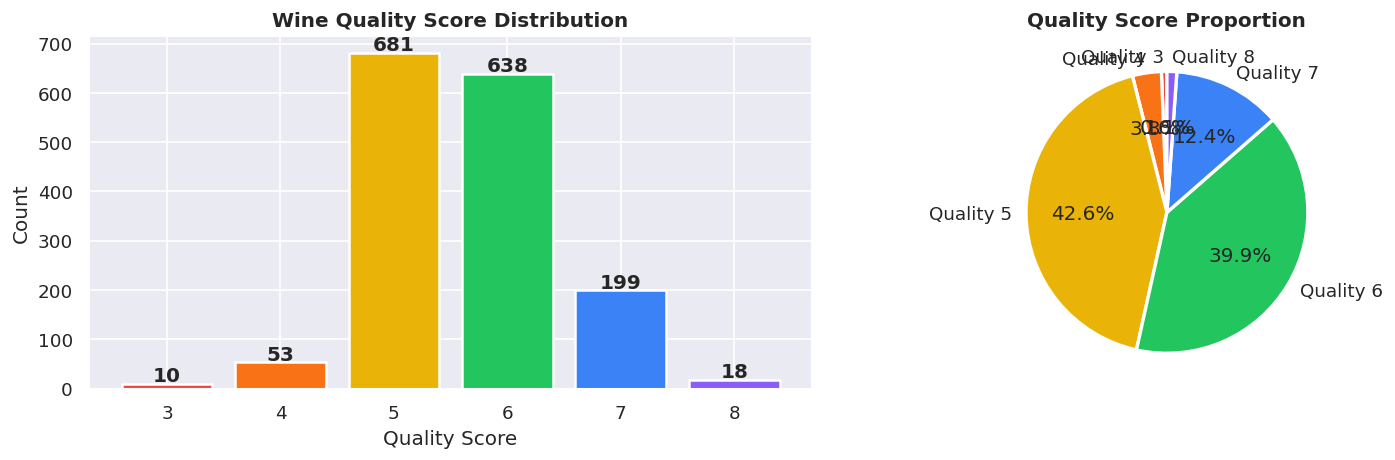

In [ ]:
print('=== Wine Quality Distribution ===')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['quality'].value_counts().sort_index()
colors = ['#ef4444','#f97316','#eab308','#22c55e','#3b82f6','#8b5cf6']
axes[0].bar(counts.index.astype(str), counts.values,
            color=colors[:len(counts)], edgecolor='white', linewidth=1.5)
axes[0].set_title('Wine Quality Score Distribution', fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')
for i, val in enumerate(counts.values):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=[f'Quality {q}' for q in counts.index],
            colors=colors[:len(counts)], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Quality Score Proportion', fontweight='bold')

plt.tight_layout()
plt.show()

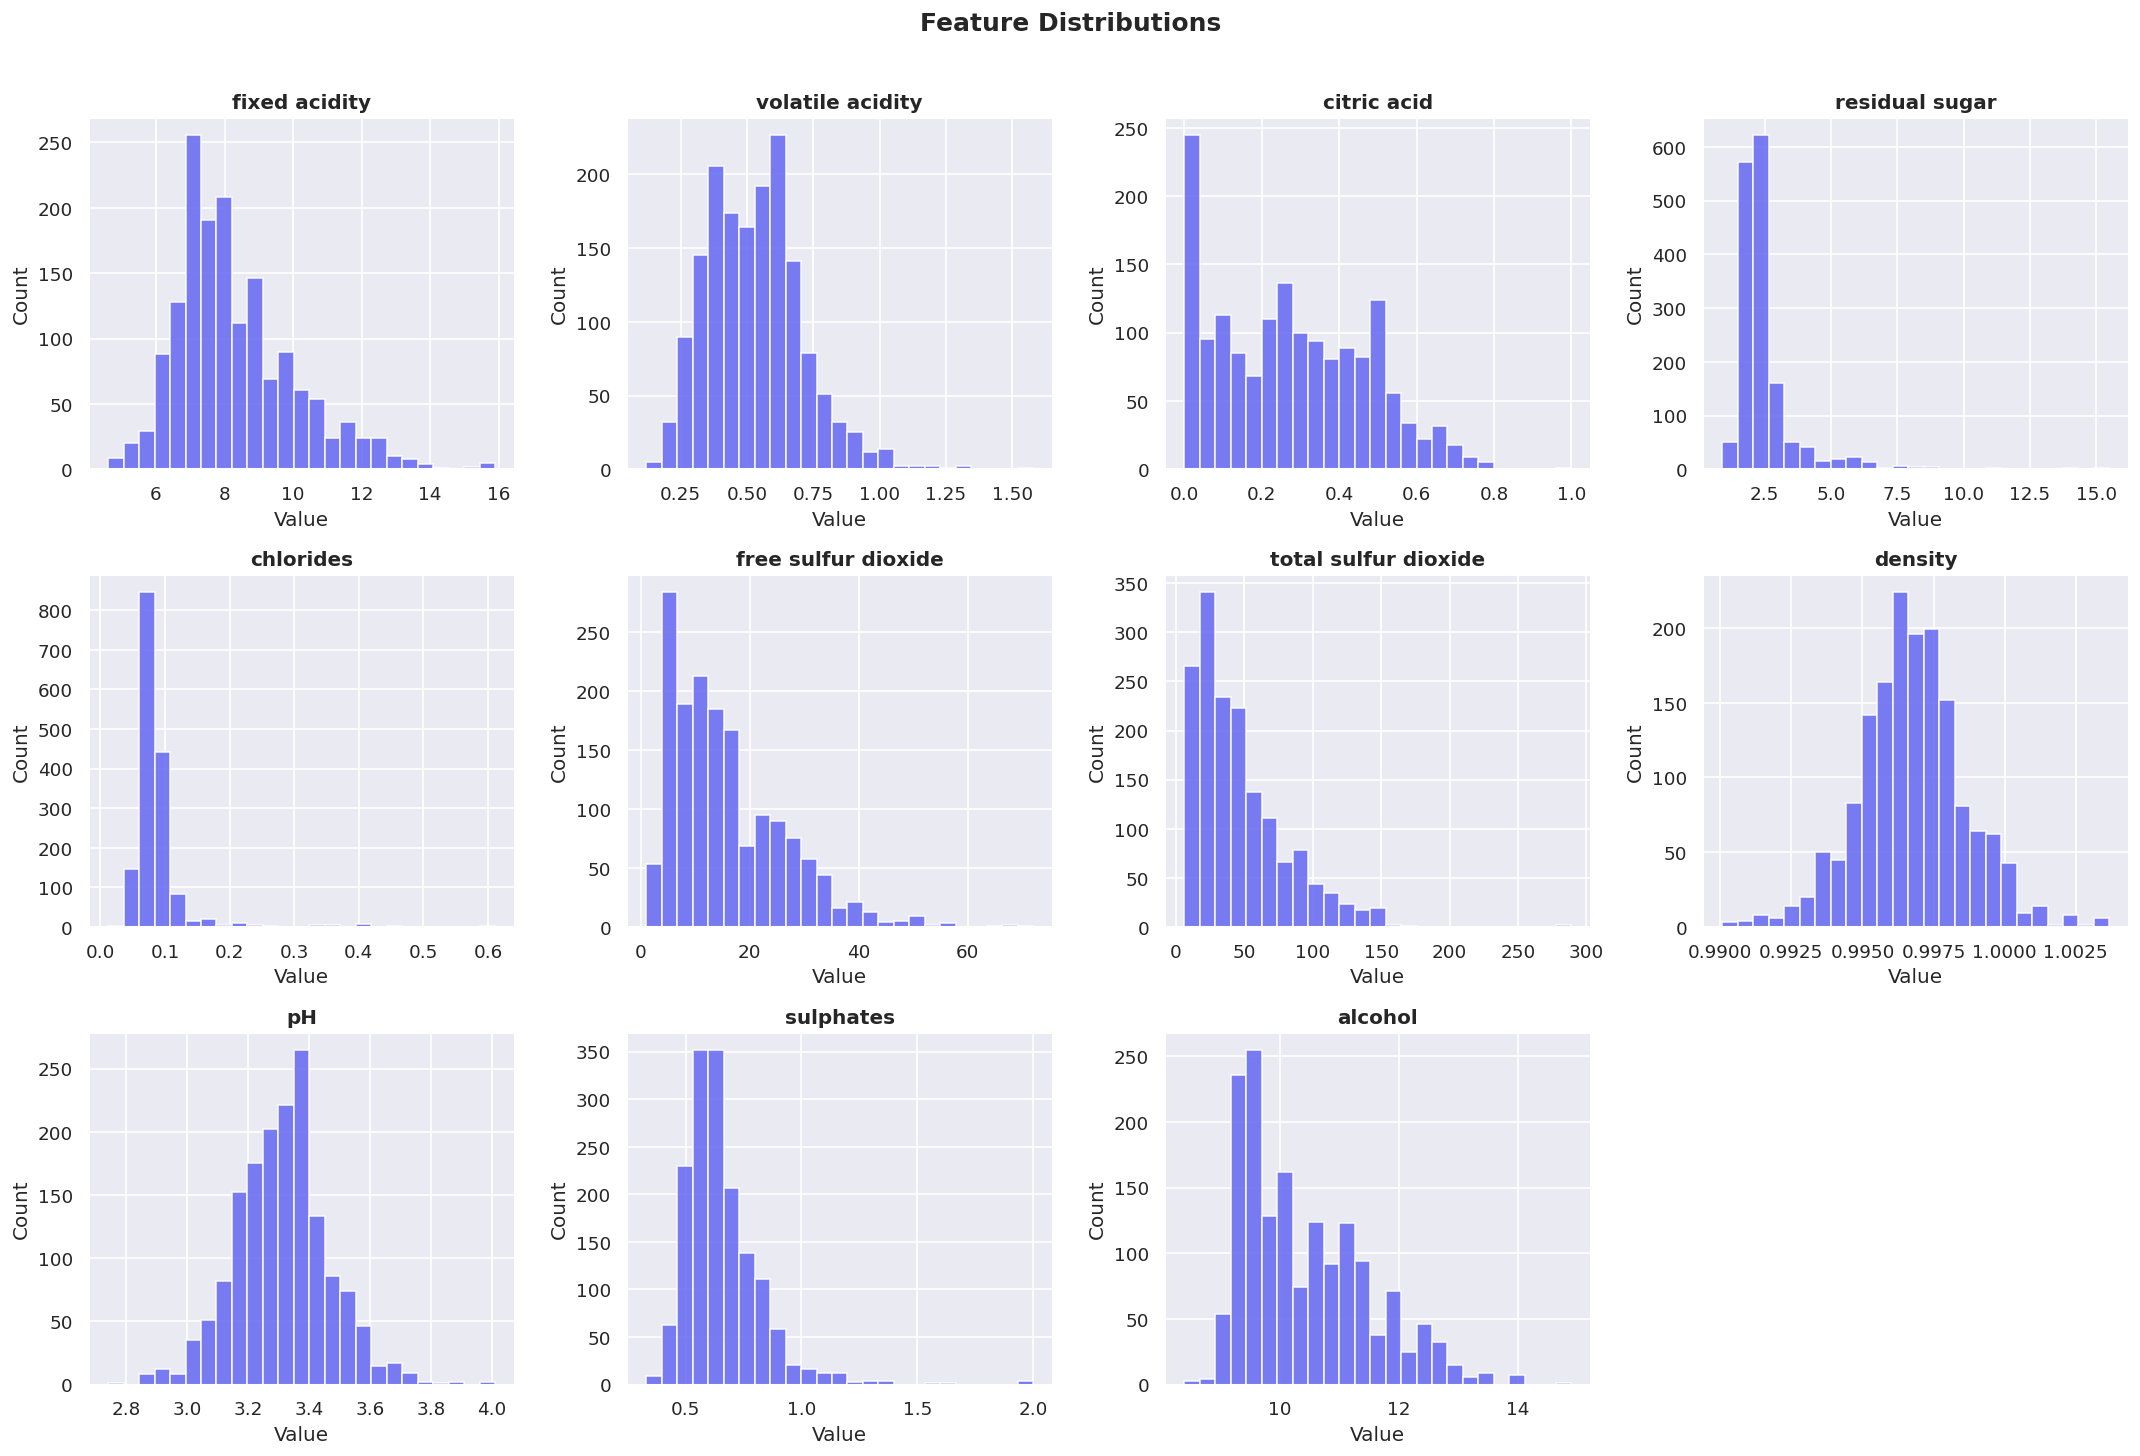

In [ ]:
features = [c for c in df.columns if c != 'quality']
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=25, color='#6366f1', edgecolor='white', alpha=0.85)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions', fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

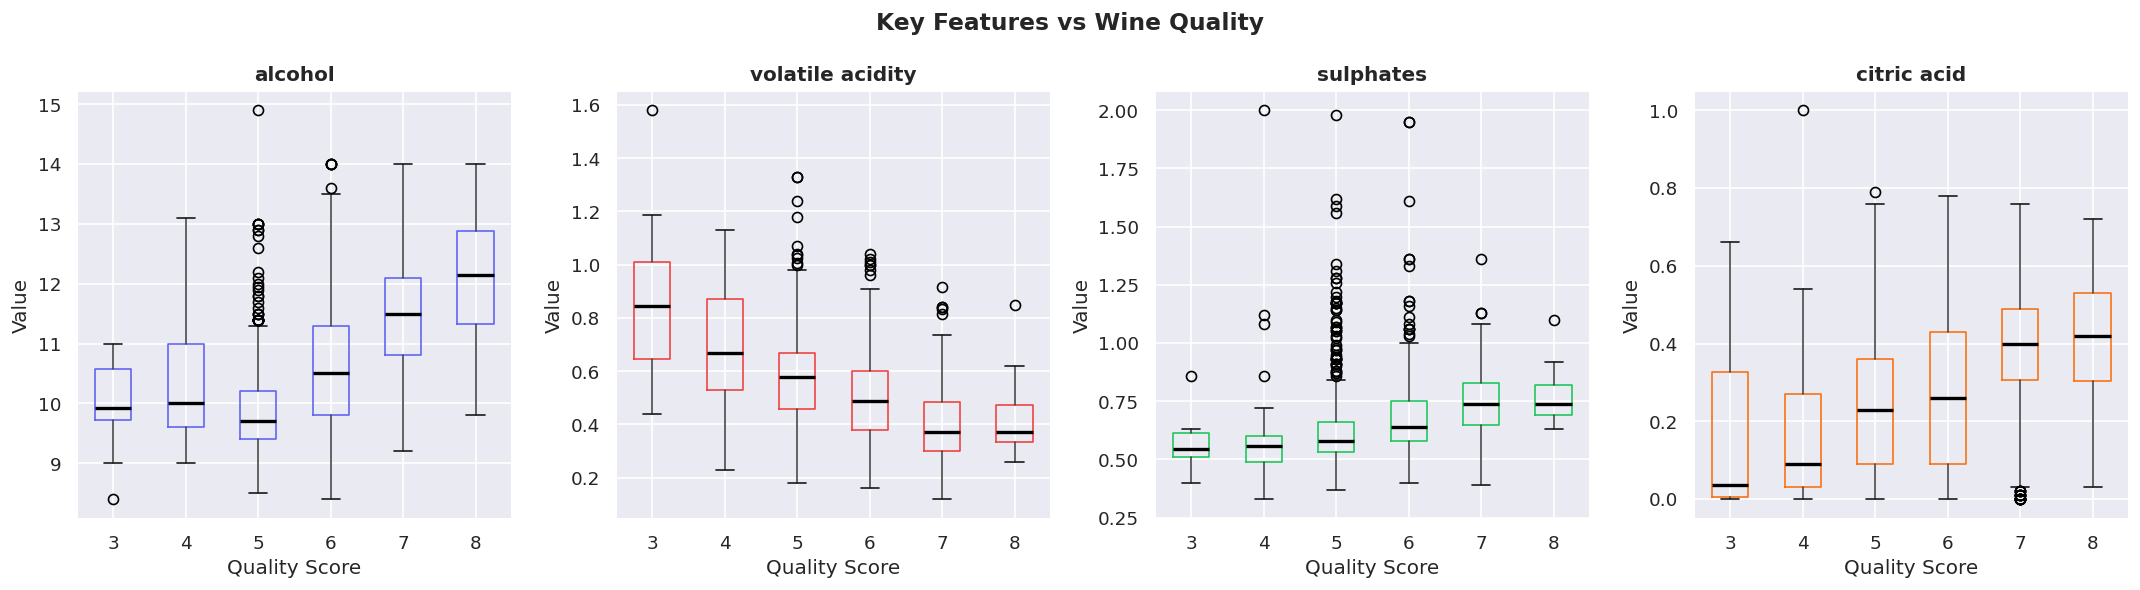

In [ ]:
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors_box = ['#6366f1', '#ef4444', '#22c55e', '#f97316']

for ax, feat, color in zip(axes, key_features, colors_box):
    df.boxplot(column=feat, by='quality', ax=ax,
               boxprops=dict(color=color),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Quality Score')
    ax.set_ylabel('Value')

plt.suptitle('Key Features vs Wine Quality', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

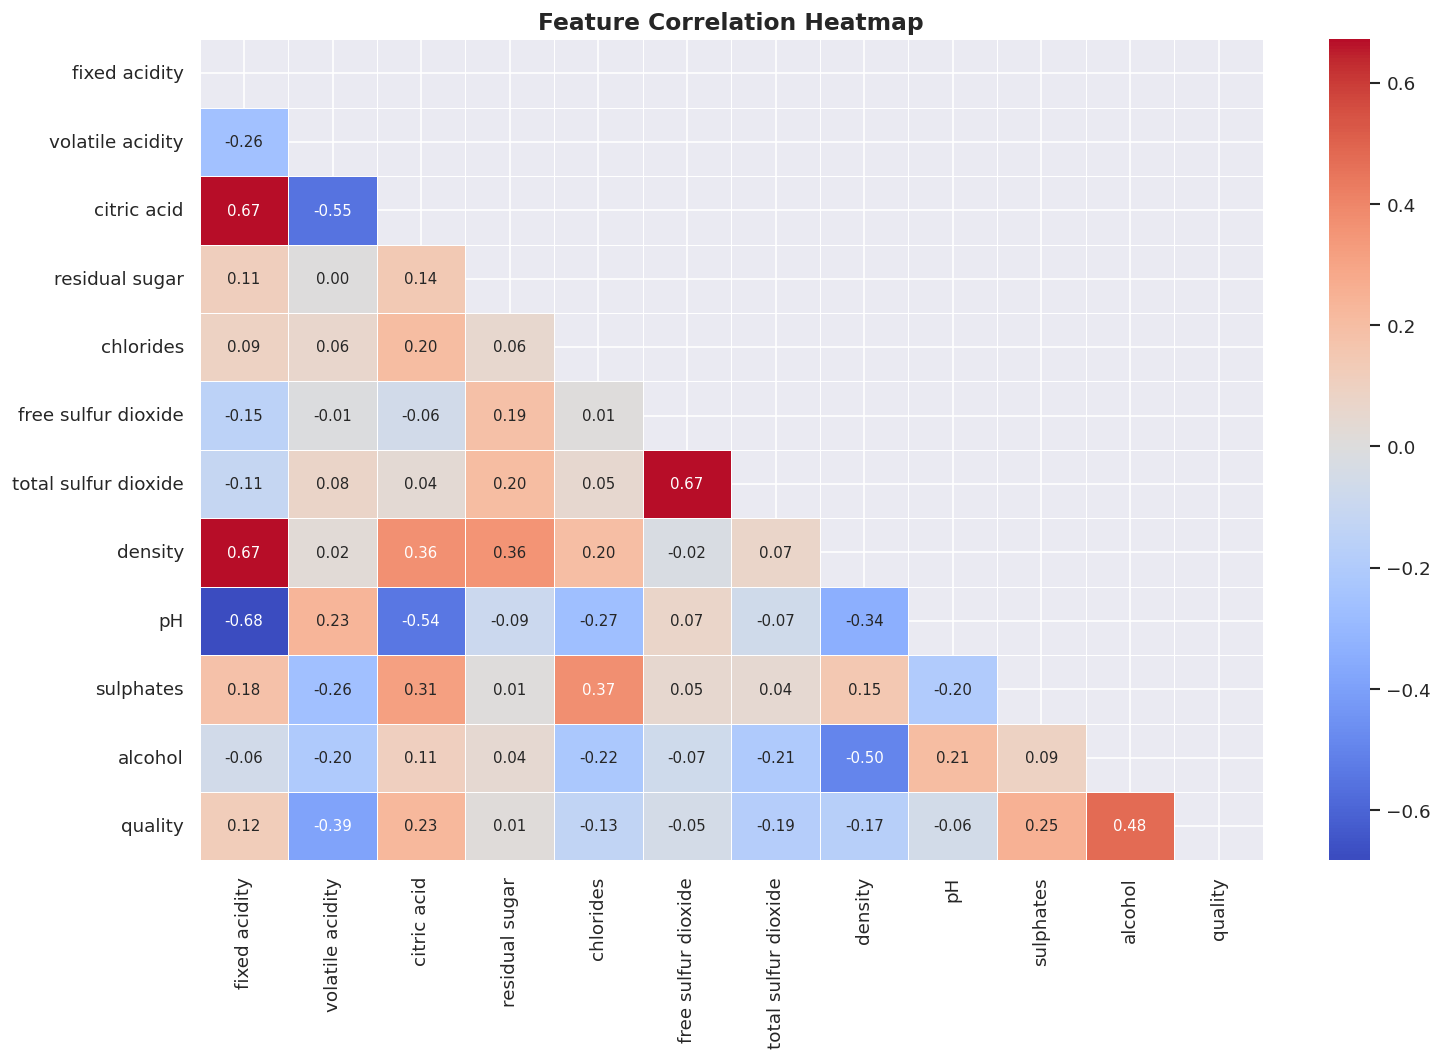

In [ ]:
plt.figure(figsize=(13, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9}, mask=mask)
plt.title('Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

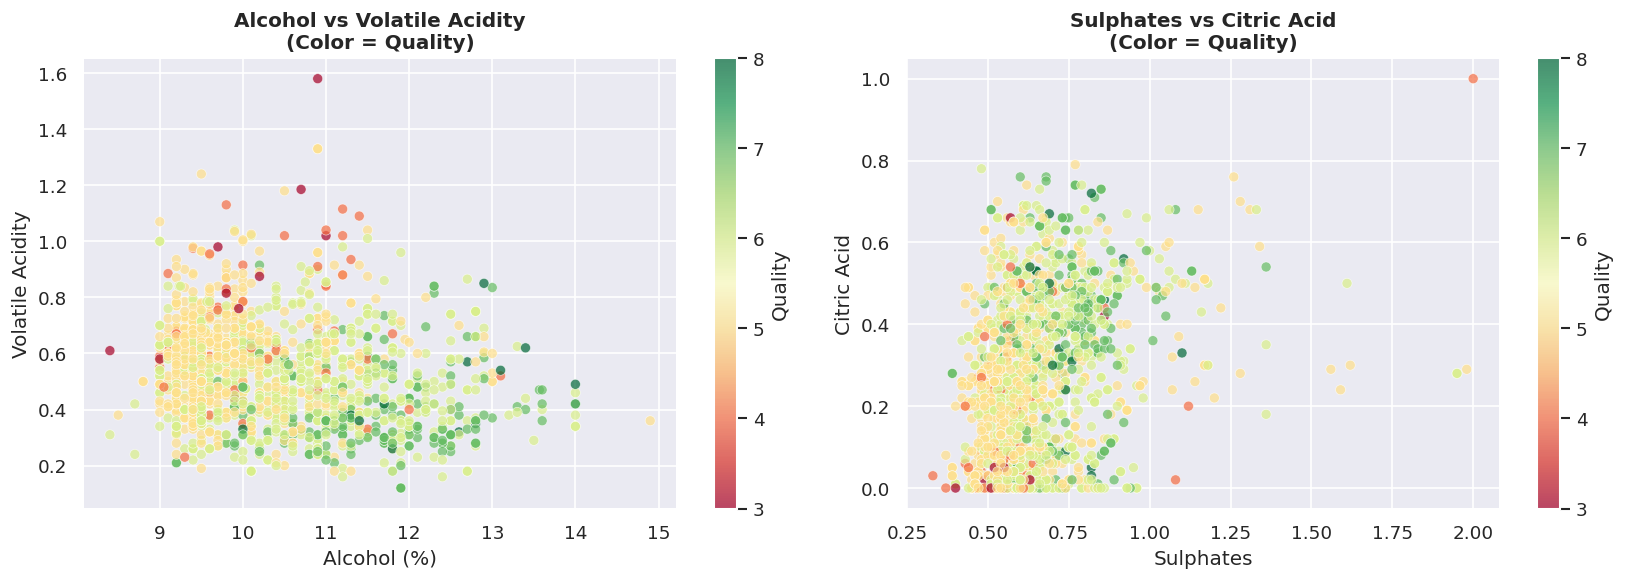

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(df['alcohol'], df['volatile acidity'],
                           c=df['quality'], cmap='RdYlGn',
                           alpha=0.7, edgecolors='white', linewidths=0.4)
axes[0].set_xlabel('Alcohol (%)')
axes[0].set_ylabel('Volatile Acidity')
axes[0].set_title('Alcohol vs Volatile Acidity\n(Color = Quality)', fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Quality')

scatter2 = axes[1].scatter(df['sulphates'], df['citric acid'],
                            c=df['quality'], cmap='RdYlGn',
                            alpha=0.7, edgecolors='white', linewidths=0.4)
axes[1].set_xlabel('Sulphates')
axes[1].set_ylabel('Citric Acid')
axes[1].set_title('Sulphates vs Citric Acid\n(Color = Quality)', fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Quality')

plt.tight_layout()
plt.show()

In [ ]:
df['quality_label'] = (df['quality'] >= 7).astype(int)

print('Quality Label Distribution:')
print(f'  Good Wine (quality ≥ 7) : {(df["quality_label"]==1).sum()} samples')
print(f'  Bad  Wine (quality < 7) : {(df["quality_label"]==0).sum()} samples')

X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

print(f'\n✅ Features : {list(X.columns)}')
print(f'   Shape    : {X.shape}')

Quality Label Distribution:
  Good Wine (quality ≥ 7) : 217 samples
  Bad  Wine (quality < 7) : 1382 samples

✅ Features : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
   Shape    : (1599, 11)


In [ ]:
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train : {len(X_train)} | Test : {len(X_test)}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Scaling Done!')

✅ Train : 1279 | Test : 320
✅ Scaling Done!


In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f'✅ {name} trained!')

✅ Logistic Regression trained!
✅ Random Forest trained!
✅ SVM trained!


In [ ]:
results = {}

print('=' * 55)
print('           MODEL EVALUATION RESULTS')
print('=' * 55)

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'accuracy' : acc,
        'auc'      : auc,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob
    }

    print(f'\n  Model    : {name}')
    print(f'  Accuracy : {acc * 100:.2f}%')
    print(f'  ROC-AUC  : {auc:.4f}')
    print('-' * 55)

           MODEL EVALUATION RESULTS

  Model    : Logistic Regression
  Accuracy : 89.38%
  ROC-AUC  : 0.8804
-------------------------------------------------------

  Model    : Random Forest
  Accuracy : 93.75%
  ROC-AUC  : 0.9547
-------------------------------------------------------

  Model    : SVM
  Accuracy : 90.00%
  ROC-AUC  : 0.8892
-------------------------------------------------------


In [ ]:
for name, res in results.items():
    print(f'\n=== {name} — Classification Report ===')
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['Bad Wine', 'Good Wine']))

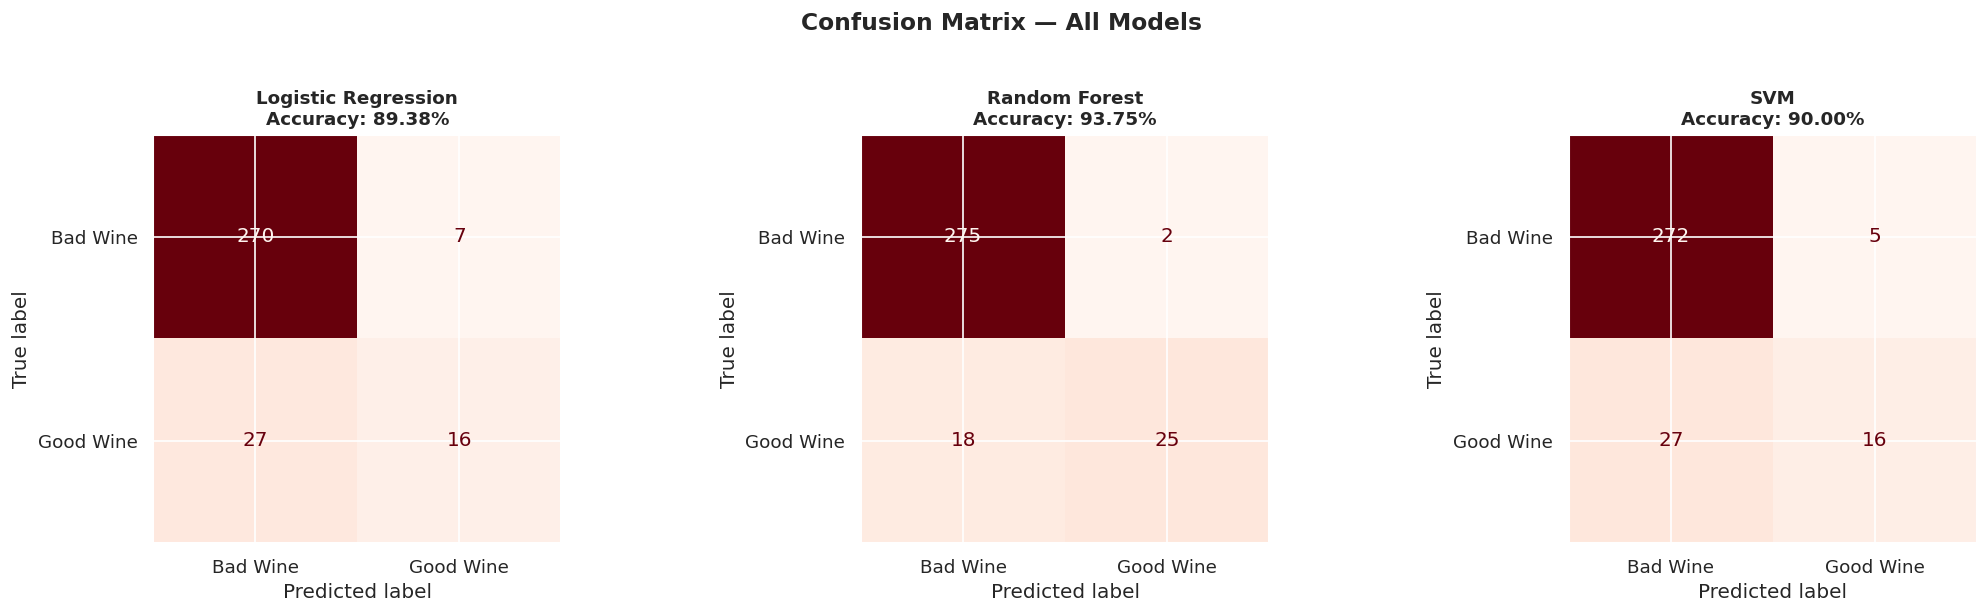

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Bad Wine', 'Good Wine'])
    disp.plot(ax=ax, colorbar=False, cmap='Reds')
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]*100:.2f}%',
                 fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrix — All Models', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

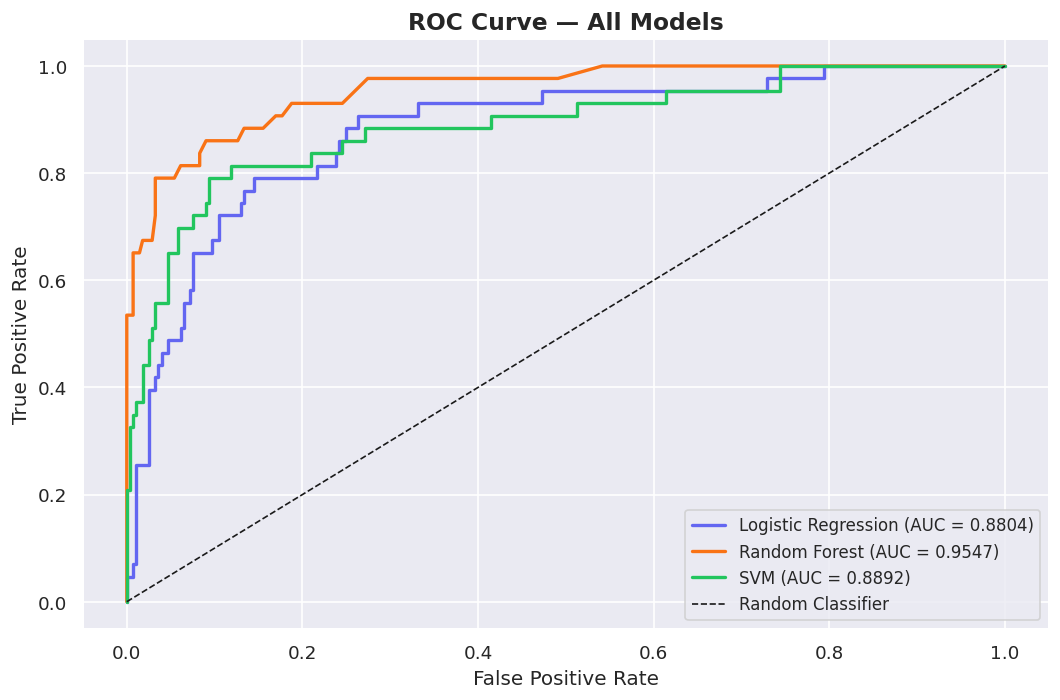

In [ ]:
plt.figure(figsize=(9, 6))
colors = ['#6366f1', '#f97316', '#22c55e']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {res["auc"]:.4f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

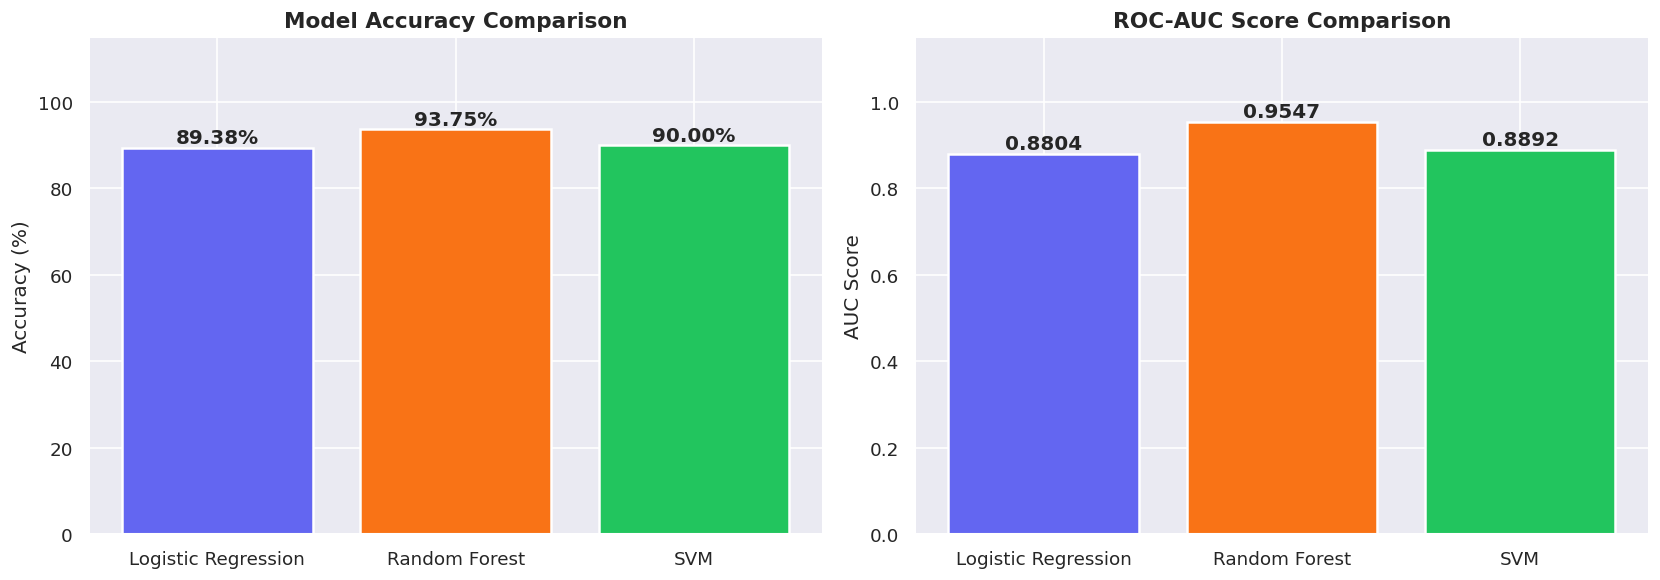

In [ ]:
model_names = list(results.keys())
accuracies  = [res['accuracy'] * 100 for res in results.values()]
aucs        = [res['auc'] for res in results.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = ['#6366f1', '#f97316', '#22c55e']

bars = axes[0].bar(model_names, accuracies, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Model Accuracy Comparison', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 115)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc:.2f}%', ha='center', fontweight='bold')

bars2 = axes[1].bar(model_names, aucs, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('ROC-AUC Score Comparison', fontweight='bold', fontsize=13)
axes[1].set_ylabel('AUC Score')
axes[1].set_ylim(0, 1.15)
for bar, auc in zip(bars2, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{auc:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import os
os.listdir()

In [ ]:
from IPython.display import Video
Video("myvideo.mp4", width=640, height=360)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
video_path = '/content/drive/MyDrive/myvideo.mp4'
print(video_path)